In [1]:
import numpy as np
import pandas as pd

import utils
utils.add_projects_to_path()
import protein_utils
#from protein_utils.sequences.msa import get_msa_from_filename
import  protein_utils.sequences.encoding as enc
from protein_utils.energy.potts import energy_calc_msa, energy_calc_single

In [2]:
seqs = pd.read_csv("../data/sequences_Oct22.tsv", sep="\t")
seqs_no_dups = seqs.drop_duplicates(["parent", "category", "ss_aa"], keep='first')
parent_seqs = seqs_no_dups[seqs_no_dups.ss_aa == "*0*"].groupby("parent").head(1)
parent_seqs.category = "P"
final_seqs = pd.concat([seqs_no_dups[seqs_no_dups.ss_aa != "*0*" ], parent_seqs])
final_seqs["response"] = final_seqs.category.map({"H":3, "P":2, "L":1, "N":0})
final_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category,response
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H,3
1,A679G,18573,1,1,K227E,False,2,1VH,H,3
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H,3
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P,2
6,"A328T,G774T",1200,2,2,"T110S,M258I",False,2,1VH,L,1
...,...,...,...,...,...,...,...,...,...,...
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N,0
1489,"T33C,T123A,A263T,A491T,G690A,C699G",116,6,3,"D41E,K88I,D164V",False,185,3VRL,N,0
3,*0*,11321,0,0,*0*,False,4,1VH,P,2
457,*0*,6378,0,0,*0*,False,1,2L,P,2


In [3]:
parent_seqs = {parent: utils.get_parent_seq(parent) for parent in final_seqs.parent.unique()}

# map the shortened sequences to full sequences
final_seqs["sequence_aa"] = final_seqs[["ss_aa", "parent"]].apply(lambda x: 
                                    utils.expand_mut_str_list_to_seq(
                                        x['ss_aa'], parent_seqs[x['parent']], 
                                        split_mut_char=",", offset=1), axis=1)

final_seqs["sequence_aa_trim"] = final_seqs.sequence_aa.str.slice(1, -1)

In [4]:
bmDCA_params_dir = "../data/scratch/bmDCA"
e_i_a_j_b = np.load(f"{bmDCA_params_dir}/sadA_e_i_a_j_b.npy")
h_i_a = np.load(f"{bmDCA_params_dir}/sadA_h_i_a.npy")

L = h_i_a.shape[0]

In [5]:
final_seqs["dca_score"] = final_seqs.sequence_aa_trim.map(lambda x:
    energy_calc_single(enc.DEFAULT_ENCODER.string_to_np(x), h_i_a=h_i_a, e_i_a_j_b=e_i_a_j_b))

In [6]:
protein_sequence_features = np.stack(final_seqs.sequence_aa_trim.map(enc.DEFAULT_NO_GAP_ENCODER.string_to_np))

In [7]:
all_features = np.hstack([protein_sequence_features,
                        final_seqs.dca_score.to_numpy()[:, np.newaxis]])

In [8]:
dataset_labels = final_seqs.parent.str.get(0).map(lambda x: int(x) - 1)
labels = final_seqs.category.to_numpy()

In [9]:
from multi_coral_pytorch import DataModule, BaseCoralModule, q, LightningMLP, pl, \
        LEARNING_RATE, WEIGHT_DECAY, NUM_EPOCHS, NUM_WORKERS, CoralMultipleLayer

In [10]:
data_module = DataModule(all_features, labels, dataset_labels, L=L)

In [11]:
import torch

In [12]:
class OneHotCoralModule(torch.nn.Module):

    def __init__(self, input_size, num_classes, num_datasets):
        
        super().__init__()

        self.num_classes = num_classes
        self.num_datasets = num_datasets
        
        # CORAL: output layer -------------------------------------------
        # Regular classifier would use the following output layer:
        # output_layer = torch.nn.Linear(hidden_units[-1], num_classes)
        
        # We replace it by the CORAL layer:
        self.output_layer = CoralMultipleLayer(size_in=input_size,
                                  num_classes=num_classes, 
                                  num_datasets=num_datasets)
        # ----------------------------------------------------------------
        
        # do not add outputlayer to all layers because
        # we send extra data (dataset information) to it in the forward
        # function
        #all_layers.append(self.output_layer)
        self.model = self.output_layer
        
    def forward(self, x, dx):
        x = self.output_layer(x, dx)
        return x
    
    def predict(self, x, dx=None):
        with torch.no_grad():
            # FIXME: this only predicts for a single x and not a batch
            return self.output_layer(x, torch.LongTensor([0])) 

In [13]:
#  pytorch_model = BaseCoralModule(
#         input_size=L*q+1,
#         hidden_units=(100, 20),
#         num_classes=4, num_datasets=dataset_labels.max()+1)

pytorch_model = OneHotCoralModule(
         input_size=L*q+1,
         num_classes=4, num_datasets=dataset_labels.max()+1)

In [14]:
  lightning_model = LightningMLP(
        model=pytorch_model,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY)

In [15]:
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
import torchmetrics

In [16]:
callbacks = [ModelCheckpoint(
    save_top_k=1, mode="min", monitor="valid_mae")]  # save top 1 model 
logger = CSVLogger(save_dir="logs/", name="mlp-three-libraries")

In [17]:
trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    callbacks=callbacks,
    #progress_bar_refresh_rate=50,  # recommended for notebooks
    accelerator="auto",  # Uses GPUs or TPUs if available
    devices="auto",  # Uses all available GPUs/TPUs if applicable
    logger=logger,
    deterministic=True,
    log_every_n_steps=10)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [18]:
import time 

start_time = time.time()
trainer.fit(model=lightning_model, datamodule=data_module)

runtime = (time.time() - start_time)/60
print(f"Training took {runtime:.2f} min in total.")


  | Name      | Type              | Params
------------------------------------------------
0 | model     | OneHotCoralModule | 5.4 K 
1 | train_mae | MeanAbsoluteError | 0     
2 | valid_mae | MeanAbsoluteError | 0     
3 | test_mae  | MeanAbsoluteError | 0     
------------------------------------------------
5.4 K     Trainable params
0         Non-trainable params
5.4 K     Total params
0.022     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


Training took 0.40 min in total.


In [19]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

aggreg_metrics = []
agg_col = "epoch"
for i, dfg in metrics.groupby(agg_col):
    agg = dict(dfg.mean())
    agg[agg_col] = i
    aggreg_metrics.append(agg)

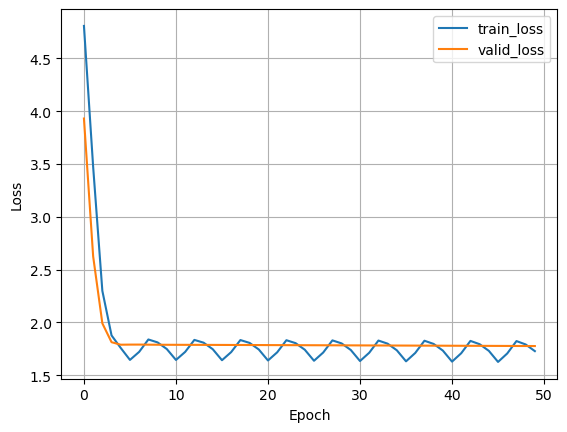

In [20]:
df_metrics = pd.DataFrame(aggreg_metrics)
x = df_metrics[["train_loss", "valid_loss"]].plot(
    grid=True, legend=True, xlabel='Epoch', ylabel='Loss')
x.get_figure().savefig("../output/three_libraries/losses.png")

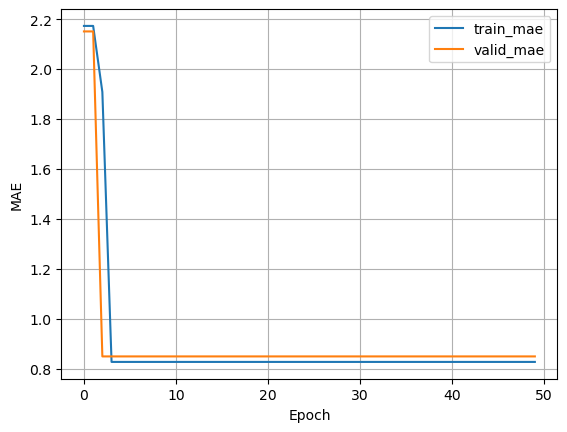

In [21]:
x = df_metrics[["train_mae", "valid_mae"]].plot(
    grid=True, legend=True, xlabel='Epoch', ylabel='MAE')
x.get_figure().savefig("../output/three_libraries/mae.png")